In [2]:
from pathlib import Path

import pandas as pd

In [3]:
files = list(Path("./orig").glob("*.csv"))

datasets = []
for file in files:
    ds = pd.read_csv(file, index_col=0)
    ds["Dataset"] = file.stem
    datasets.append(ds)

df = pd.concat(datasets)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import colormaps as cm


def create_horizontal_paired_boxplots_with_duplicates(df):
    """
    Create horizontal paired boxplots comparing original and averaged datasets with annotations
    showing the number of duplicates for each dataset using pure matplotlib.

    Parameters:
    df (pandas.DataFrame): DataFrame with columns 'Dataset', 'Smiles', and 'Standard Value'

    Returns:
    matplotlib.figure.Figure: The figure containing the plot
    """
    # Calculate the averaged dataset
    avg_df = (
        df.groupby(["Dataset", "Smiles"])["Standard Value"].agg(["mean"]).reset_index()
    )
    avg_df = avg_df.rename(columns={"mean": "Standard Value"})

    # Use the already computed averaged data from avg_df
    avg_plot_data = avg_df[["Dataset", "Smiles", "Standard Value"]]

    # Get unique datasets and sort them
    datasets = sorted(df["Dataset"].unique())
    n_datasets = len(datasets)

    # Create figure with appropriate margins
    fig, ax = plt.subplots(figsize=(14, max(6, n_datasets * 1.2)))

    # Define colors for paired boxplots using Tab20 colormap

    tab20_cmap = cm.get_cmap("tab20")

    # Map the colors for consistent pairing
    colors = []
    for i in range(n_datasets):
        # Use consecutive pairs from Tab20
        original_color = tab20_cmap(i * 2)
        averaged_color = tab20_cmap(i * 2 + 1)
        colors.append((original_color, averaged_color))

    # Calculate positions on y-axis - each dataset gets one position
    positions = np.arange(n_datasets)

    # Prepare data for boxplots - separate lists for original and averaged
    original_data = []
    averaged_data = []

    for dataset in datasets:
        # Add original data for this dataset
        original_values = df[df["Dataset"] == dataset]["Standard Value"].values
        original_data.append(original_values)

        # Add averaged data for this dataset
        averaged_values = avg_plot_data[avg_plot_data["Dataset"] == dataset][
            "Standard Value"
        ].values
        averaged_data.append(averaged_values)

    # Box properties
    box_width = 0.35  # Narrower boxes to fit side by side
    whisker_props = dict(linestyle="-", linewidth=1.5, color="black")
    cap_props = dict(linestyle="-", linewidth=1.5, color="black")
    median_props = dict(
        linestyle="-", linewidth=2.0, color="black"
    )  # Black median line
    meanprops = dict(linestyle="--", linewidth=2.0, color="black")  # Black median line

    # Create original boxplots - offset to the left
    original_pos = [p + box_width / 2 for p in positions]
    original_boxes = ax.boxplot(
        original_data,
        vert=False,
        positions=original_pos,
        widths=box_width,
        patch_artist=True,
        meanline=True,
        showmeans=True,
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="none",
            alpha=0.5,
        ),
        whiskerprops=whisker_props,
        capprops=cap_props,
        meanprops=meanprops,
        medianprops=median_props,  # Apply black median line
    )

    # Create averaged boxplots - offset to the right
    averaged_pos = [p - box_width / 2 for p in positions]
    averaged_boxes = ax.boxplot(
        averaged_data,
        vert=False,
        positions=averaged_pos,
        widths=box_width,
        patch_artist=True,
        meanline=True,
        showmeans=True,
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="none",
            alpha=0.5,
        ),
        whiskerprops=whisker_props,
        capprops=cap_props,
        meanprops=meanprops,
        medianprops=median_props,  # Apply black median line
    )

    # Apply colors to boxes
    for i, box in enumerate(original_boxes["boxes"]):
        box.set(facecolor=colors[i][0], edgecolor="black", linewidth=1.5)

    for i, box in enumerate(averaged_boxes["boxes"]):
        box.set(facecolor=colors[i][1], edgecolor="black", linewidth=1.5)

    # Add horizontal lines between datasets
    for i in range(1, n_datasets):
        y_pos = i - 0.5
        ax.axhline(y=y_pos, color="gray", linestyle="--", alpha=0.5)

    # Add y-axis labels - just the dataset names once
    ax.set_yticks(positions)
    ax.set_yticklabels(datasets)

    # Compute duplicates
    duplicates = df[df[["Dataset", "Smiles"]].duplicated()].groupby("Dataset").size()

    # Add annotation for dataset size and duplicates
    for i, dataset in enumerate(datasets):
        n_duplicates = duplicates.get(dataset, 0)
        total = len(df[df["Dataset"] == dataset])
        y_pos = positions[i]

        # Duplicate information text
        text = (
            f"Total: {total}\n"
            f"Duplicates: {n_duplicates} ({n_duplicates / total * 100:.1f}%)"
        )

        # Position duplicate text on the right for original (left) boxplot
        x_pos = ax.get_xlim()[1] * 0.99

        # Add text annotations with background boxes
        # Place duplicate info above the boxplot
        ax.text(
            x_pos,
            y_pos - 0.5,
            text,
            ha="right",
            va="center",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.9, boxstyle="round,pad=0.3"),
        )

    # Add grid lines
    ax.grid(axis="x", linestyle="--", alpha=0.7)

    # Formatting
    ax.set_title("Comparison of Original vs. Averaged Values by Dataset", fontsize=14)
    ax.set_xlabel("Standard Value", fontsize=12)

    # Add legend
    legend_elements = [
        Patch(facecolor=colors[0][0], edgecolor="black", label="Original"),
        Patch(facecolor=colors[0][1], edgecolor="black", label="Averaged"),
    ]
    ax.legend(handles=legend_elements, loc="upper right")

    # Add more space on the right for annotations
    plt.subplots_adjust(right=0.85, left=0.1)

    return avg_df

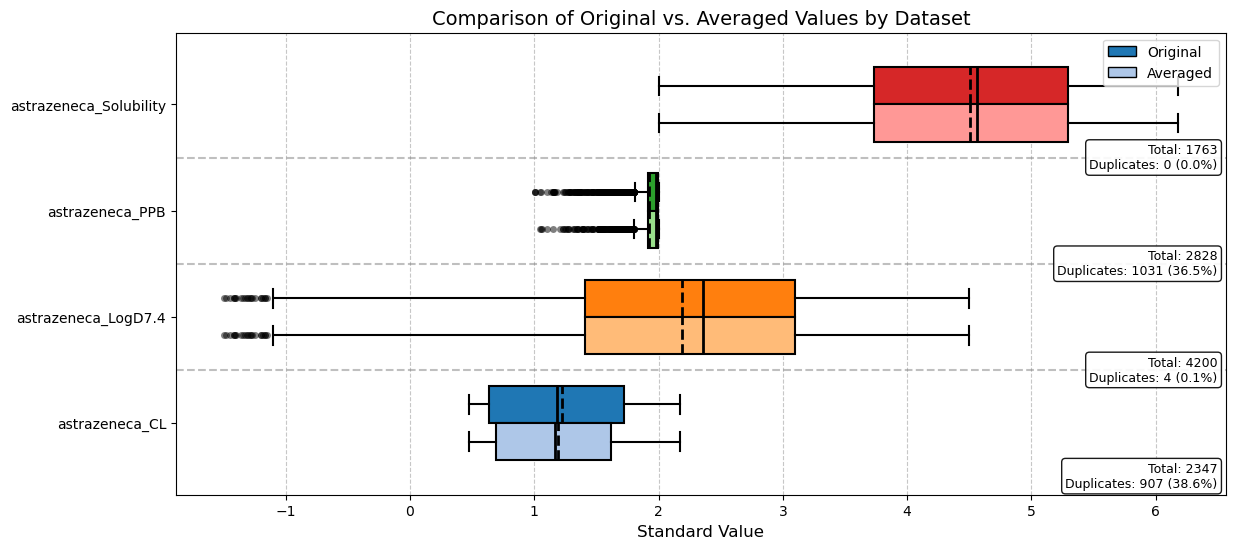

In [15]:
avg = create_horizontal_paired_boxplots_with_duplicates(df)

In [7]:
for name, group in avg.groupby("Dataset"):
    group = group.reset_index(drop=True)
    group = group.rename(columns={"Smiles": "smiles"})

    group[["smiles", "Standard Value"]].to_csv(f"result/{name}.csv")